## 1. Setup

### 1.0 Google Drive Sync

In [87]:
# Adicionar o conteúdo do drive no caminho do sistema

#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

In [88]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!ls

[Errno 2] No such file or directory: '/content/drive/MyDrive/projetos-if702/projeto-churn/'
/Users/thomaz/Documents/CIn-UFPE/2026.1/projetos-if702/projeto-churn
0_preprocessamento.ipynb churn_preprocessing.py   results
1_MLP.ipynb              datasets                 searches
2_XGBoost.ipynb          ml_utils.py              split_churn.py
__pycache__              models


In [89]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [90]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.1 Importar Libs

In [91]:
# Importação das bibliotecas necessárias
import pandas as pd
import optuna 
import optuna.visualization as optuna_vis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, loguniform, randint
from joblib import dump, load
import warnings


warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
import torch
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load

from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
)
from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL
try:
    import xgboost as xgb
except:
    print("❌ XGBoost não encontrado. Instale com: pip install xgboost")

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

Bibliotecas importadas com sucesso!
Pandas: 3.0.3
NumPy: 2.4.6
Scikit-learn: 1.8.0
XGBoost: 3.2.0
Device: CPU


### 1.2 Configuração do Modelo

In [92]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "XGBoost"
MODEL_CLASS = xgb.XGBClassifier
#RANDOM_STATE_MODEL = 42
#RANDOM_STATE_SAMPLE = 10

# Configuração da busca de hiperparâmetros
#N_SEARCHES = 20
#N_ITER_PER_SEARCH = 5
#SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search

module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)

print("Hiperparâmetros disponíveis na classe do modelo:")
for param in MODEL_CLASS().get_params().keys():
    print(f"  - {param}")

Modelo configurado: XGBoost
xgboost.sklearn
Hiperparâmetros disponíveis na classe do modelo:
  - objective
  - base_score
  - booster
  - callbacks
  - colsample_bylevel
  - colsample_bynode
  - colsample_bytree
  - device
  - early_stopping_rounds
  - enable_categorical
  - eval_metric
  - feature_types
  - feature_weights
  - gamma
  - grow_policy
  - importance_type
  - interaction_constraints
  - learning_rate
  - max_bin
  - max_cat_threshold
  - max_cat_to_onehot
  - max_delta_step
  - max_depth
  - max_leaves
  - min_child_weight
  - missing
  - monotone_constraints
  - multi_strategy
  - n_estimators
  - n_jobs
  - num_parallel_tree
  - random_state
  - reg_alpha
  - reg_lambda
  - sampling_method
  - scale_pos_weight
  - subsample
  - tree_method
  - validate_parameters
  - verbosity


## 2. Carregamento e Preparação dos Dados

In [93]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

X_train_scaled = X_train
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [94]:
train_data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Sampling para Busca de Hiperparâmetros

### 3.0 Sampling para busca

In [95]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


Dataset original de treino: 5,174 amostras
Amostra para busca de hiperparâmetros: 259 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {0: 130, 1: 129}
Original: {0: 2587, 1: 2587}


### 3.1 Configs da Busca Optuna

In [96]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [97]:
# Optuna
n_trials = 100
scoring_metric = 'ks'
loss_fn = get_loss_fn('cross_entropy')

# modelos PyTorch somente
early_stopping_patience = 10
early_stopping_delta = 0.001
training_epochs_per_trial = 10

### 3.2 Definição do espaço de hiperparâmetros

In [98]:
param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "n_estimators": {"type": "int", "values": [100, 500]},
        "max_depth": {"type": "int", "values": [3, 10]},
        "learning_rate": {"type": "float", "values": [1e-3, 0.3, None, True]},
        "subsample": {"type": "float", "values": [0.5, 1.0]},
        "colsample_bytree": {"type": "float", "values": [0.3, 1.0]},
        "reg_alpha": {"type": "float", "values": [1e-5, 10.0, None, True]},
        "reg_lambda": {"type": "float", "values": [1e-5, 10.0, None, True]},
        "min_child_weight": {"type": "int", "values": [1, 20]},
        "gamma": {"type": "float", "values": [0.0, 1.0]},
    },
)

print_hyperparameter_space(param_space)

Hyperparameter space:
- n_estimators: type=int, args=[100, 500], kwargs={}
- max_depth: type=int, args=[3, 10], kwargs={}
- learning_rate: type=float, args=[0.001, 0.3], kwargs={'log': True}
- subsample: type=float, args=[0.5, 1.0], kwargs={}
- colsample_bytree: type=float, args=[0.3, 1.0], kwargs={}
- reg_alpha: type=float, args=[1e-05, 10.0], kwargs={'log': True}
- reg_lambda: type=float, args=[1e-05, 10.0], kwargs={'log': True}
- min_child_weight: type=int, args=[1, 20], kwargs={}
- gamma: type=float, args=[0.0, 1.0], kwargs={}


### 3.3 Executar Busca de Hiperparâmetros

In [99]:
print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Trials: {n_trials}")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")
print(f"Hiperparâmetros no espaço: {list(param_space.keys())}")

direction = "minimize" if scoring_metric in {"val_loss", "loss"} else "maximize"
study = run_optuna_search(
    model_class=MODEL_CLASS,
    space=param_space,
    X_train=X_sample,
    y_train=y_sample,
    X_val=X_val,
    y_val=y_val,
    n_trials=n_trials,
    direction=direction,
    scoring_metric=scoring_metric,
    device=device,
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta,
    loss_fn=loss_fn,
)

print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score ({scoring_metric}): {study.best_value:.6f}")

[I 2026-06-04 16:03:52,515] A new study created in memory with name: no-name-e6ca57a4-ff20-40a1-a3dd-f3b91cc88663
[I 2026-06-04 16:03:52,569] Trial 0 finished with value: 0.47795823665893267 and parameters: {'n_estimators': 339, 'max_depth': 3, 'learning_rate': 0.02039745099339167, 'subsample': 0.7408718016022425, 'colsample_bytree': 0.48413246139232957, 'reg_alpha': 1.6259353636636644, 'reg_lambda': 0.004377571933832226, 'min_child_weight': 17, 'gamma': 0.9413100110058601}. Best is trial 0 with value: 0.47795823665893267.


=== BUSCA DE HIPERPARÂMETROS - XGBoost ===
Iniciando busca de hiperparâmetros para XGBoost...
Trials: 100
Usando amostra de 259 exemplos

Hiperparâmetros no espaço: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda', 'min_child_weight', 'gamma']


[I 2026-06-04 16:03:52,628] Trial 1 finished with value: 0.49419953596287697 and parameters: {'n_estimators': 306, 'max_depth': 10, 'learning_rate': 0.001691368707905106, 'subsample': 0.7297299174235408, 'colsample_bytree': 0.796064542877114, 'reg_alpha': 3.1204649131619386, 'reg_lambda': 0.00042444314983118396, 'min_child_weight': 14, 'gamma': 0.4222460707617993}. Best is trial 1 with value: 0.49419953596287697.
[I 2026-06-04 16:03:52,673] Trial 2 finished with value: 0.5003866976024749 and parameters: {'n_estimators': 296, 'max_depth': 3, 'learning_rate': 0.06697409505294301, 'subsample': 0.6646446793985061, 'colsample_bytree': 0.5072794592817046, 'reg_alpha': 0.2496558356893947, 'reg_lambda': 2.6141571454572987, 'min_child_weight': 9, 'gamma': 0.9870596315069806}. Best is trial 2 with value: 0.5003866976024749.
[I 2026-06-04 16:03:52,737] Trial 3 finished with value: 0.4810518174787316 and parameters: {'n_estimators': 426, 'max_depth': 4, 'learning_rate': 0.10509999673117291, 'subsa


--- RESULTADOS XGBoost ---
Melhores hiperparâmetros encontrados:
  n_estimators: 433
  max_depth: 9
  learning_rate: 0.0014349708088042794
  subsample: 0.5566948986105161
  colsample_bytree: 0.4191759361797791
  reg_alpha: 0.0002197777396581099
  reg_lambda: 0.007587218485697329
  min_child_weight: 1
  gamma: 0.6627972889165209

Melhor score (ks): 0.518948


### 3.4 Visualizar histórico da busca

In [100]:
optuna_vis.plot_param_importances(study)

In [101]:
optuna_vis.plot_optimization_history(study, target_name=scoring_metric)

In [102]:
optuna_vis.plot_parallel_coordinate(study, params=list(param_space.keys()), target_name=scoring_metric)

In [103]:
print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS - {MODEL_NAME} ===")

trials_df = study.trials_dataframe()
if "state" in trials_df.columns:
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]
sorted_df = trials_df.sort_values("value", ascending=(direction == "minimize"))

print(f"\nTop configurações (de {len(sorted_df)} trials completos):")
print(sorted_df.head(10).to_string(index=False))

if not sorted_df.empty:
    print(f"\nEstatísticas dos scores encontrados:")
    print(f"  Média: {sorted_df['value'].mean():.4f}")
    print(f"  Mediana: {sorted_df['value'].median():.4f}")
    print(f"  Desvio padrão: {sorted_df['value'].std():.4f}")
    print(f"  Min: {sorted_df['value'].min():.4f}")
    print(f"  Max: {sorted_df['value'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - XGBoost ===

Top configurações (de 100 trials completos):
 number    value             datetime_start          datetime_complete               duration  params_colsample_bytree  params_gamma  params_learning_rate  params_max_depth  params_min_child_weight  params_n_estimators  params_reg_alpha  params_reg_lambda  params_subsample    state
     87 0.518948 2026-06-04 16:04:03.777833 2026-06-04 16:04:03.978991 0 days 00:00:00.201158                 0.419176      0.662797              0.001435                 9                        1                  433          0.000220           0.007587          0.556695 COMPLETE
     99 0.518175 2026-06-04 16:04:06.084982 2026-06-04 16:04:06.288668 0 days 00:00:00.203686                 0.335479      0.730684              0.001965                 9                        1                  456          0.000060           0.049092          0.562820 COMPLETE
     98 0.518175 2026-06-04 16:04:05.882708 2026-06-

## 4. Salvar Resultados de Busca

In [104]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

trials_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_trials.csv")
best_params_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_best.json")

trials_df.to_csv(trials_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

print("Resultados da busca salvos:")
print(trials_path)
print(best_params_path)

Resultados da busca salvos:
searches/xgboost_optuna_trials.csv
searches/xgboost_optuna_best.json


In [105]:
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [106]:
if os.path.exists(trials_path):
    loaded_trials_df = pd.read_csv(trials_path)
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        loaded_best_params = json.load(f)

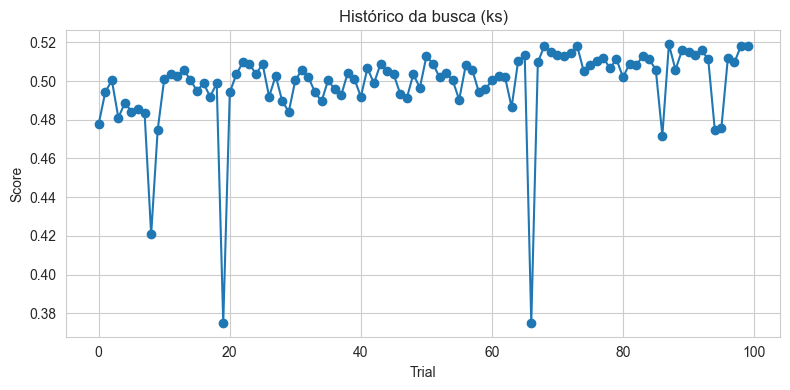

In [107]:
# Plotar a história da busca a partir dos resultados carregados
if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
    plot_df = loaded_trials_df.sort_values("number") if "number" in loaded_trials_df.columns else loaded_trials_df
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["value"].values, marker="o")
    plt.title(f"Histórico da busca ({scoring_metric})")
    plt.xlabel("Trial")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

## 6. Definir Melhores Params e Score de Busca

In [108]:
# Definir Melhores Parâmetros para Uso Posterior
if loaded_best_params is not None:
    best_params = loaded_best_params
    if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
        best_score = (
            loaded_trials_df["value"].min()
            if direction == "minimize"
            else loaded_trials_df["value"].max()
        )
    else:
        best_score = study.best_value
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor score carregado: {best_score:.6f}")
else:
    best_params = study.best_params
    best_score = study.best_value
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor score da busca atual: {best_score:.6f}")

✅ Usando parâmetros carregados: {'n_estimators': 433, 'max_depth': 9, 'learning_rate': 0.0014349708088042794, 'subsample': 0.5566948986105161, 'colsample_bytree': 0.4191759361797791, 'reg_alpha': 0.0002197777396581099, 'reg_lambda': 0.007587218485697329, 'min_child_weight': 1, 'gamma': 0.6627972889165209}
✅ Melhor score carregado: 0.518948


## 7. Treinar Modelo Final e Salvar

In [109]:
best_model = MODEL_CLASS(**best_params, random_state=RANDOM_STATE_MODEL)
best_model.fit(X_train_scaled, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.4191759361797791
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [110]:
# Salvar o modelo treinado com os melhores hiperparâmetros 
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)

print(f" Model saved to: {model_path}")

 Model saved to: models/xgboost_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [111]:
# Carregar modelo (Opcional)
loaded_model = load(model_path)

In [112]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model, X_train_eval, y_train_eval, device=device
 )
test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model, X_test_eval, y_test_eval, device=device
 )

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - XGBoost ===

Avaliando: XGBoost


### 8.1 Classification Report

In [113]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1294
           1       0.54      0.73      0.62       468

    accuracy                           0.76      1762
   macro avg       0.71      0.75      0.72      1762
weighted avg       0.79      0.76      0.77      1762



KS Statistic: 0.5196


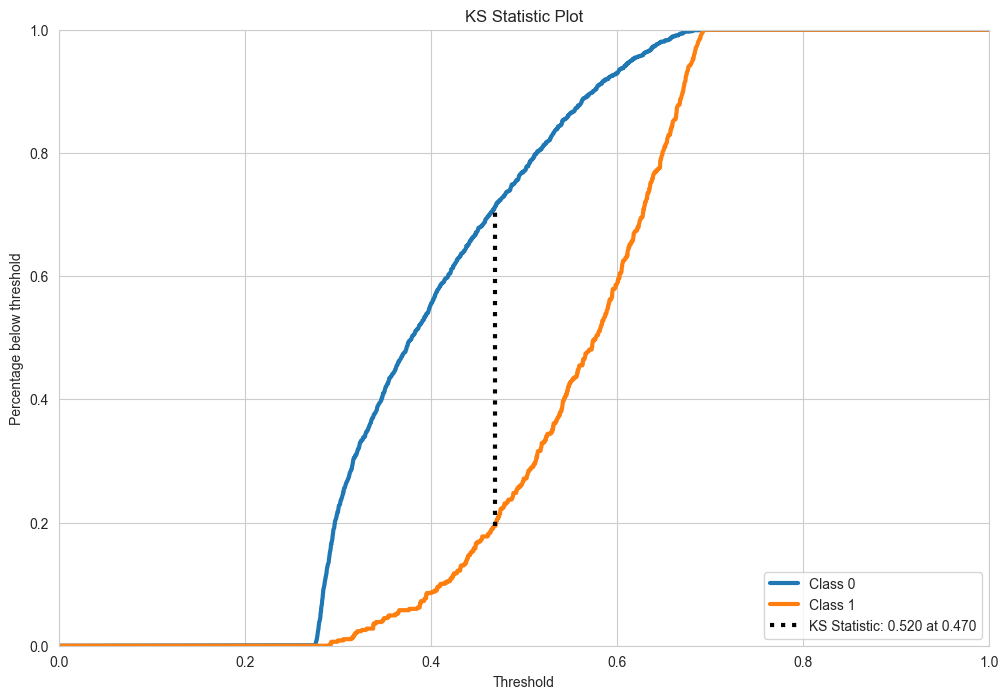

In [114]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)

### 8.2 Visualize Confusion Matrix

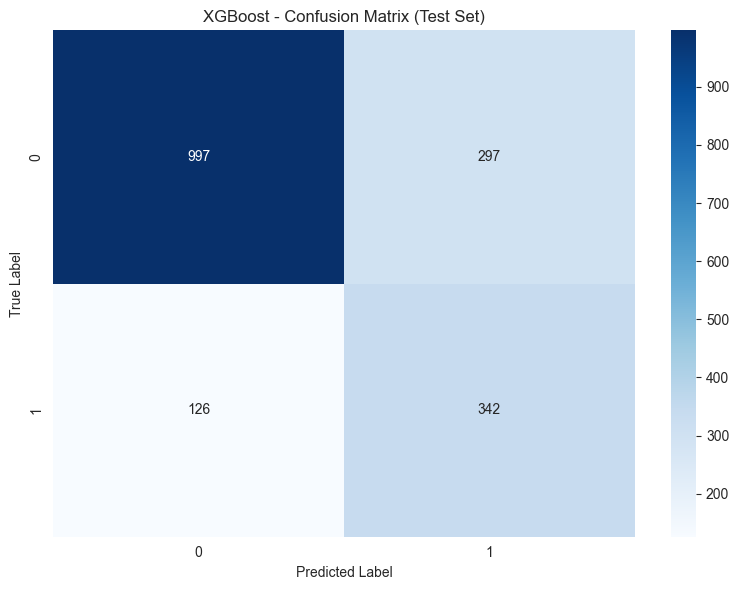

In [115]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [116]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL XGBoost ---
Score da busca: 0.518948
KS Statistic Teste: 0.5196
AUC-ROC Teste: 0.8367
F1-Score Teste: 0.6179
Acurácia Teste: 0.7599
Precisão Teste: 0.5352
Recall Teste: 0.7308
Resultados salvos em: results/
Arquivo final: results/xgboost_final_results.json
